In [ ]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import torch
import math

In [ ]:
torch.manual_seed(20)

In [ ]:
# Parameters
n = 50        # number of data points
d = 2         # dimension
device = 'cpu'

## Construction of Datasets

In [ ]:
# dataset 0: equidistant and not parallel
if n % 2 == 0: # avoids parallel points
  n = n+1
print('We cosider', n, 'datapoints.')
angles = torch.linspace(0, 2*np.pi, n+1)[:-1]
X_0 = torch.stack([torch.cos(angles), torch.sin(angles)], dim=1)
angles_0 = torch.atan2(X_0[:, 1], X_0[:, 0])
Y_0 = torch.sin(4*angles_0)

# dataset A: no parallelity
X_A = torch.randn(n, d, device=device)
normX_A = X_A / torch.norm(X_A, dim=1, keepdim=True)
angles_A = torch.atan2(normX_A[:, 1], normX_A[:, 0])
Y_A = torch.sin(4*angles_A)


# dataset B: includes some parallel vectors
mu = torch.zeros(d)
cov = torch.tensor([1.0, 3.0])

X_B = torch.normal(mu.repeat(n, 1), cov.repeat(n, 1))
normX_B = X_B / torch.norm(X_B, dim=1, keepdim=True)
angles_B = torch.atan2(normX_B[:, 1], normX_B[:, 0])
Y_B = torch.sin(4*angles_B)


# dataset C: dataset B with added parallel vectors
X_C = X_B
for i in range(round(n/2)):
  X_C = torch.cat([X_C, X_C[i].unsqueeze(0)])
normX_C = X_C / torch.norm(X_C, dim=1, keepdim=True)
angles_C = torch.atan2(normX_C[:, 1], normX_C[:, 0])
Y_C = torch.sin(4*angles_C)


# dataset D: lots of parallel vectors
mu_2 = torch.zeros(d)
cov_2 = torch.tensor([1.0, 50.0])

X_D = torch.normal(mu_2.repeat(n, 1), cov_2.repeat(n, 1))
normX_D = X_D / torch.norm(X_D, dim=1, keepdim=True)
angles_D = torch.atan2(normX_D[:, 1], normX_D[:, 0])
Y_D = torch.sin(4*angles_D)

We cosider 51 datapoints.


In [ ]:
# function that checks for parallelity within a tolerance

def check_parallelity(X, Y, name, delete=True, TOL=1e-7):
  min = 0
  count = 0
  initial_shape = X.shape[0]
  i = 0
  while i < X.shape[0]:
    j = i + 1
    while j < X.shape[0]:
      if torch.abs(torch.dot(X[i], X[j])) >= 1 - TOL:
        if delete == True:
          X = torch.cat([X[0:j], X[j+1:]])
          Y = torch.cat([Y[0:j], Y[j+1:]])
          count = count + 1
        else:
          count = count + 1
      elif (torch.abs(torch.dot(X[i], X[j]))) > min:
        min = torch.abs(torch.dot(X[i], X[j]))
      j = j + 1
    i = i + 1

  if delete == True:
    print('Deleted', initial_shape - X.shape[0], 'datapoints from set', name, 'to avoid parallel datapoints.')
  else:
    print('Set', name, 'includes', count, 'pairs of parallel datapoints.')

  return X, Y, min

In [ ]:
# check datasets for parallel points

X_0, Y_0, min0 = check_parallelity(X_0, Y_0, 'X_0')
normX_A, Y_A, minA = check_parallelity(normX_A, Y_A, 'X_A')
normX_B, Y_B, minB = check_parallelity(normX_B, Y_B, 'X_B', False)
normX_C, Y_C, minC = check_parallelity(normX_C, Y_C, 'X_C', False)
normX_D, Y_D, minD = check_parallelity(normX_D, Y_D, 'X_D', False)

Deleted 0 datapoints from set X_0 to avoid parallel datapoints.
Deleted 0 datapoints from set X_A to avoid parallel datapoints.
Set X_B includes 0 pairs of parallel datapoints.
Set X_C includes 25 pairs of parallel datapoints.
Set X_D includes 18 pairs of parallel datapoints.


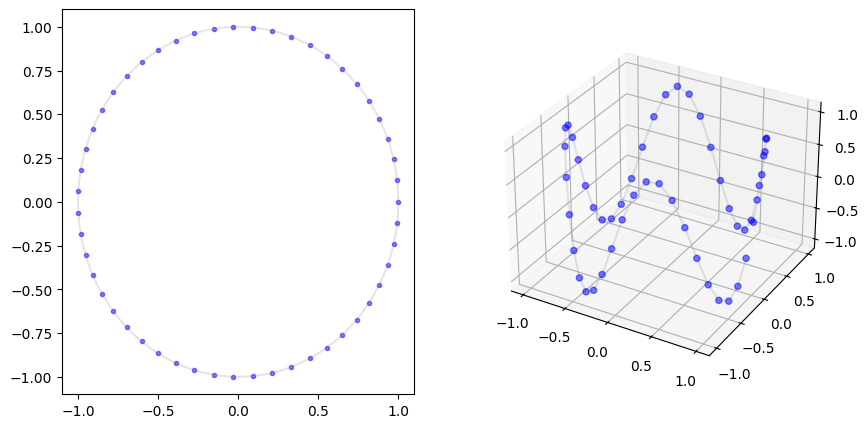

In [ ]:
# plot dataset X_0

fig = plt.figure(figsize=(10, 5))

theta = np.linspace(0, 2 * np.pi, 150)
x = np.cos(theta)
y = np.sin(theta)

ax0 = fig.add_subplot(1, 2, 1)
ax0.plot(X_0[:, 0], X_0[:, 1], '.', color='blue', alpha = 0.5)
ax0.plot(x, y, alpha = 0.2, color = 'gray')

ax1 = fig.add_subplot(1, 2, 2, projection='3d')
ax1.scatter(X_0[:, 0], X_0[:, 1], Y_0, color='blue', alpha = 0.5)
ax1.plot(X_0[:, 0], X_0[:, 1], Y_0, color='gray', alpha = 0.2)

#fig.suptitle('Dataset X_0')
plt.show()

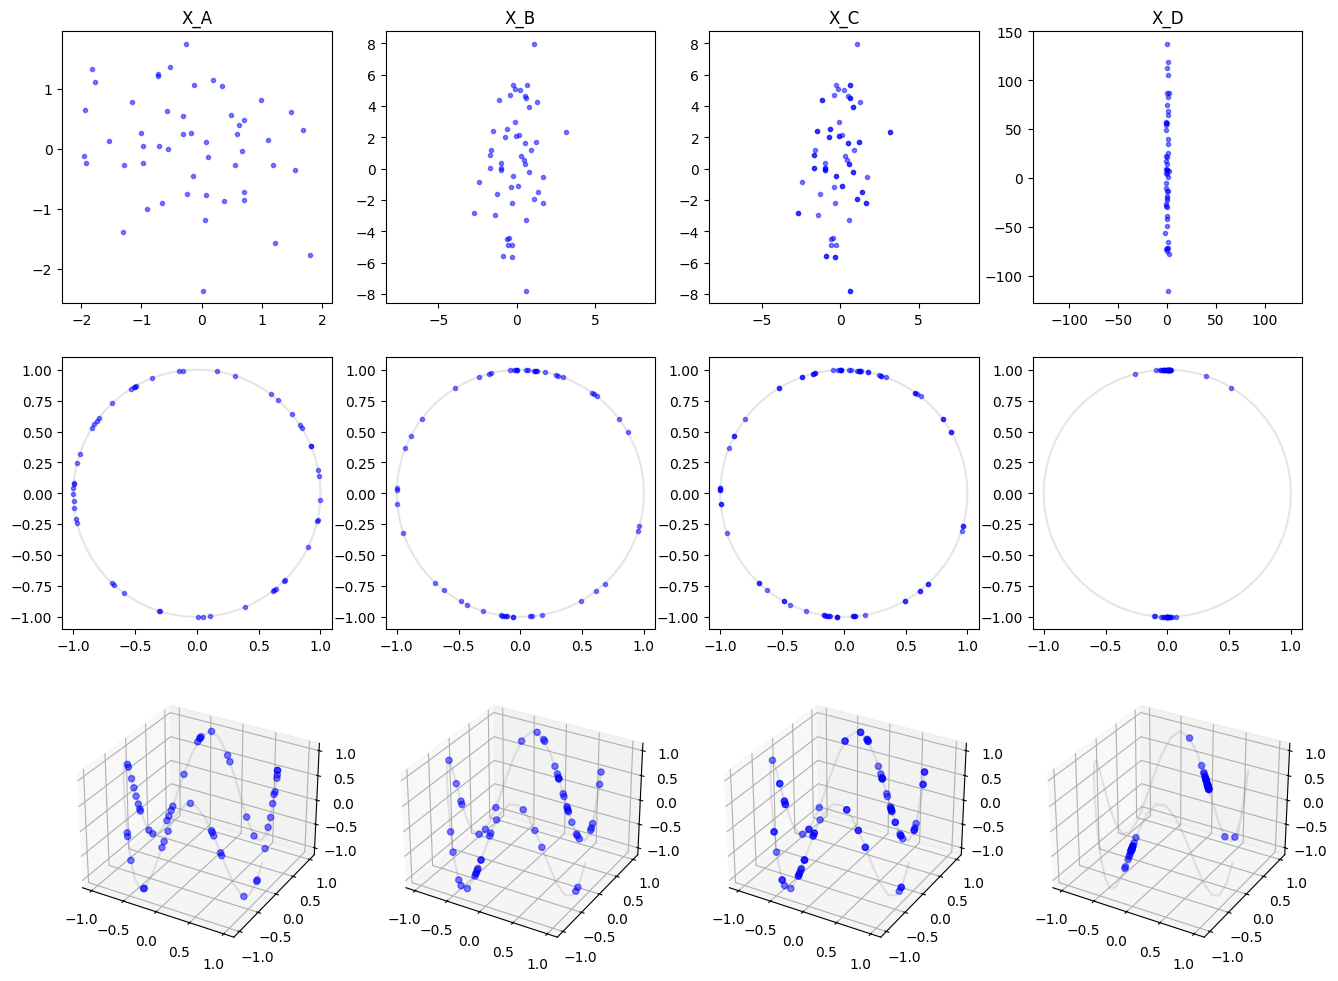

In [ ]:
# plot datasets X_A, X_B, X_C, X_D

fig, axs = plt.subplots(3, 4, figsize=(16, 12))

# plot distribution of datapoints
axs[0][0].plot(X_A[:, 0], X_A[:, 1], '.', color='blue', alpha = 0.5)
axs[0][0].set_title('X_A')
axs[0][0].axis("equal")

axs[0][1].plot(X_B[:, 0], X_B[:, 1], '.', color='blue', alpha = 0.5)
axs[0][1].set_title('X_B')
axs[0][1].axis("equal")

axs[0][2].plot(X_C[:, 0], X_C[:, 1], '.', color='blue', alpha = 0.5)
axs[0][2].set_title('X_C')
axs[0][2].axis("equal")

axs[0][3].plot(X_D[:, 0], X_D[:, 1], '.', color='blue', alpha = 0.5)
axs[0][3].set_title('X_D')
axs[0][3].axis("equal")


# plot normalized data points
axs[1][0].plot(x, y, alpha = 0.2, color = 'gray')
axs[1][1].plot(x, y, alpha = 0.2, color = 'gray')
axs[1][2].plot(x, y, alpha = 0.2, color = 'gray')
axs[1][3].plot(x, y, alpha = 0.2, color = 'gray')

axs[1][0].plot(normX_A[:, 0], normX_A[:, 1], '.', color='blue', alpha = 0.5)
#axs[1][0].set_title('normalized X_A')
axs[1][0].set_xlim([-1, 1])
axs[1][0].axis("equal")

axs[1][1].plot(normX_B[:, 0], normX_B[:, 1], '.', color='blue', alpha = 0.5)
#axs[1][1].set_title('normalized X_B')
axs[1][1].set_ylim([-1, 1])
axs[1][1].axis("equal")

axs[1][2].plot(normX_C[:, 0], normX_C[:, 1], '.', color='blue', alpha = 0.5)
#axs[1][2].set_title('normalized X_C')
axs[1][2].set_xlim([-1, 1])
axs[1][2].axis("equal")

axs[1][3].plot(normX_D[:, 0], normX_D[:, 1], '.', color='blue', alpha = 0.5)
#axs[1][3].set_title('normalized X_D')
axs[1][3].set_xlim([-1, 1])
axs[1][3].axis("equal")

# plot 3D view
axs[2][0].remove()
axs[2][0] = fig.add_subplot(3, 4, 9, projection='3d')
axs[2][0].scatter(normX_A[:, 0], normX_A[:, 1], Y_A, color='blue', alpha=0.5)
axs[2][0].plot(X_0[:, 0], X_0[:, 1], Y_0, color='gray', alpha=0.2)
#axs[2][0].set_title('3D View')

axs[2][1].remove()
axs[2][1] = fig.add_subplot(3, 4, 10, projection='3d')
axs[2][1].scatter(normX_B[:, 0], normX_B[:, 1], Y_B, color='blue', alpha=0.5)
axs[2][1].plot(X_0[:, 0], X_0[:, 1], Y_0, color='gray', alpha=0.2)
#axs[2][1].set_title('3D View')

axs[2][2].remove()
axs[2][2] = fig.add_subplot(3, 4, 11, projection='3d')
axs[2][2].scatter(normX_C[:, 0], normX_C[:, 1], Y_C, color='blue', alpha=0.5)
axs[2][2].plot(X_0[:, 0], X_0[:, 1], Y_0, color='gray', alpha=0.2)
#axs[2][2].set_title('3D View')

axs[2][3].remove()
axs[2][3] = fig.add_subplot(3, 4, 12, projection='3d')
axs[2][3].scatter(normX_D[:, 0], normX_D[:, 1], Y_D, color='blue', alpha=0.5)
axs[2][3].plot(X_0[:, 0], X_0[:, 1], Y_0, color='gray', alpha=0.2)
#axs[2][3].set_title('3D View')

plt.show()

## Gram matrix and its least eigenvalue

In [ ]:
# compute the Gram matrix of a dataset X

def gram_matrix(X):
  H = torch.zeros((X.shape[0], X.shape[0]))

  for i in range(X.shape[0]):
    for j in range(i, X.shape[0]):
      rho = torch.clamp(torch.dot(X[i], X[j]), -1.0, 1.0) # ensures rho \in [-1, 1]
      H[i, j] = torch.clamp(torch.dot(X[i], X[j]), -1.0, 1.0)*(0.25 + (torch.arcsin(rho) / (2 * math.pi)))
      if i != j:
        H[j, i] = H[i, j]

  return H

In [ ]:
# returns the least eigenvalue of a matrix H

def compute_lambda_min(H):
    eigenvalues = torch.linalg.eigvalsh(H)   # eigenvalues are returned in ascending order
    return eigenvalues[0]

In [ ]:
H_0 = gram_matrix(X_0)
H_A = gram_matrix(normX_A)
H_B = gram_matrix(normX_B)
H_C = gram_matrix(normX_C)
H_D = gram_matrix(normX_D)

lambda_0 = compute_lambda_min(H_0)
lambda_A = compute_lambda_min(H_A)
lambda_B = compute_lambda_min(H_B)
lambda_C = compute_lambda_min(H_C)
lambda_D = compute_lambda_min(H_D)

print(lambda_0)
print(lambda_A)
print(lambda_B)
print(lambda_C)
print(lambda_D)

tensor(0.0049)
tensor(0.0002)
tensor(0.0001)
tensor(-1.0153e-06)
tensor(-4.1065e-05)


In [ ]:
def gram_matrix_of_k(X, W, a, m):
  H = torch.zeros(X.shape[0], X.shape[0])

  preActivation = X @ W # Shape (n, m)

  for i in range(X.shape[0]):
    for j in range(i, X.shape[0]):

      indicator = (preActivation[i, :] >= 0) & (preActivation[j, :] >= 0)

      H[i, j] = (1 / m) * torch.clamp(torch.dot(X[i], X[j]), -1.0, 1.0) * (torch.square(a) * indicator.float()).sum()

      if i != j:
        H[j, i] = H[i, j]

  return H

In [ ]:
def norm(H):
  return torch.sum(H**2)

## Neural Network with one,two and three hidden layers and ReLU activation

In [ ]:
class NeuralNetwork(torch.nn.Module):
    def __init__(self, d, m):
        super().__init__()
        self.W = torch.nn.Parameter(torch.randn(d, m, device=device))
        self.a = torch.nn.Parameter((-1)**torch.bernoulli(1/2 * torch.ones(m, device=device)))
        self.m = m

    def forward(self, X):
        Z = torch.relu(X @ self.W)
        U = (Z * self.a).sum(dim=1) / math.sqrt(self.m)
        return U

In [ ]:
class DeepNeuralNetwork(torch.nn.Module):
    def __init__(self, d, m):
        super().__init__()
        self.W1 = torch.nn.Parameter(torch.randn(d, m, device=device))
        self.W2 = torch.nn.Parameter(torch.randn(m, m, device=device))
        self.a = torch.nn.Parameter((-1)**torch.bernoulli(1/2 * torch.ones(m, device=device)))
        self.m = m

    def forward(self, X):
        Z1 = torch.relu(X @ self.W1)
        Z2 = torch.relu(Z1 @ self.W2)
        U = (Z2 * self.a).sum(dim=1) / math.sqrt(self.m)
        return U

In [ ]:
class DeeperNeuralNetwork(torch.nn.Module):
    def __init__(self, d, m):
        super().__init__()
        self.W1 = torch.nn.Parameter(torch.randn(d, m, device=device))
        self.W2 = torch.nn.Parameter(torch.randn(m, m, device=device))
        self.W3 = torch.nn.Parameter(torch.randn(m, m, device=device))
        self.a = torch.nn.Parameter((-1)**torch.bernoulli(1/2 * torch.ones(m, device=device)))
        self.m = m

    def forward(self, X):
        Z1 = torch.relu(X @ self.W1)
        Z2 = torch.relu(Z1 @ self.W2)
        Z3 = torch.relu(Z2 @ self.W3)
        U = (Z3 * self.a).sum(dim=1) / math.sqrt(self.m)
        return U

## Comparison for increasing width on Neural Networks with one, two and three hidden layers

In [ ]:
m = [1, 10, 100, 1000, 10000]#, 100000]
eta = 0.1
epochs = 10000

In [ ]:
# plots for dataset X_0

plotY_0 = []

for i in range(len(m)):
  plotX_0 = []

  print(f"Training on dataset X_0 for m = {m[i]}")
  model = NeuralNetwork(d, m[i])
  optimizer = torch.optim.SGD([model.W, model.a], lr=eta)

  for epoch in range(epochs):
    optimizer.zero_grad()
    U = model(X_0)
    loss = 0.5 * torch.mean((U - Y_0) ** 2)

    if (epoch < 10) | ((epoch < 100) & ((epoch+1) % 10 == 0)) | ((epoch < 1000) & ((epoch+1) % 100 == 0)) | (epoch == 0) | ((epoch < 10000) & ((epoch+1) % 1000 == 0)) | ((epoch+1) % 10000 == 0):
      print('Epoch', epoch+1, 'Loss:', np.round(loss.item(), decimals=10))
      plotY_0.append(loss.item())
      plotX_0.append(epoch+1)

    loss.backward()
    optimizer.step()

Training on dataset X_0 for m = 1
Epoch 1 Loss: 1.1167192459
Epoch 2 Loss: 1.1166855097
Epoch 3 Loss: 1.1166518927
Epoch 4 Loss: 1.1166183949
Epoch 5 Loss: 1.1165846586
Epoch 6 Loss: 1.1165509224
Epoch 7 Loss: 1.1165173054
Epoch 8 Loss: 1.1164836884
Epoch 9 Loss: 1.1164499521
Epoch 10 Loss: 1.1164163351
Epoch 20 Loss: 1.1160799265
Epoch 30 Loss: 1.1157436371
Epoch 40 Loss: 1.1154073477
Epoch 50 Loss: 1.1150710583
Epoch 60 Loss: 1.1147350073
Epoch 70 Loss: 1.1143989563
Epoch 80 Loss: 1.1140630245
Epoch 90 Loss: 1.1137270927
Epoch 100 Loss: 1.1133913994
Epoch 200 Loss: 1.1100420952
Epoch 300 Loss: 1.1067063808
Epoch 400 Loss: 1.1033872366
Epoch 500 Loss: 1.1000798941
Epoch 600 Loss: 1.0967922211
Epoch 700 Loss: 1.0935186148
Epoch 800 Loss: 1.0902569294
Epoch 900 Loss: 1.087018609
Epoch 1000 Loss: 1.0837919712
Epoch 2000 Loss: 1.0523341894
Epoch 3000 Loss: 1.0223096609
Epoch 4000 Loss: 0.9936356544
Epoch 5000 Loss: 0.9662331343
Epoch 6000 Loss: 0.9400427341
Epoch 7000 Loss: 0.9149867296
E

In [ ]:
'''fig = plt.figure(figsize=(5, 5))

for i in range(len(m)):
  plt.loglog(plotX_0, plotY_0[i*len(plotX_0):(i+1)*len(plotX_0)], label = f'm = {m[i]}')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('2-layer Neural Network')

plt.show()'''

"fig = plt.figure(figsize=(5, 5))\n\nfor i in range(len(m)):\n  plt.loglog(plotX_0, plotY_0[i*len(plotX_0):(i+1)*len(plotX_0)], label = f'm = {m[i]}')\n\nplt.xlabel('Epoch')\nplt.ylabel('Loss')\nplt.legend()\nplt.title('2-layer Neural Network')\n\nplt.show()"

In [ ]:
# plots for dataset X_0

all_plotY_0mod = []
all_plotX_0mod = []

for i in range(len(m)):
  current_plotY = []
  current_plotX = []

  print(f"Training on dataset X_0 for m = {m[i]}")
  model = DeepNeuralNetwork(d, m[i])
  optimizer = torch.optim.SGD([model.W1, model.W2, model.a], lr=eta)

  for epoch in range(epochs):
    optimizer.zero_grad()
    U = model(X_0)
    loss = 0.5 * torch.mean((U - Y_0) ** 2)

    if ((epoch < 10) | ((epoch < 100) & ((epoch+1) % 10 == 0)) | ((epoch < 1000) & ((epoch+1) % 100 == 0)) | (epoch == 0) | ((epoch < 10000) & ((epoch+1) % 1000 == 0)) | ((epoch+1) % 10000 == 0)) and (not torch.isnan(loss)):
      print('Epoch', epoch+1, 'Loss:', np.round(loss.item(), decimals=10))
      current_plotY.append(loss.item())
      current_plotX.append(epoch+1)

    loss.backward()
    optimizer.step()

    if torch.isnan(loss) or torch.isinf(loss):
      break

  all_plotY_0mod.append(current_plotY)
  all_plotX_0mod.append(current_plotX)

Training on dataset X_0 for m = 1
Epoch 1 Loss: 0.2499999553
Epoch 2 Loss: 0.2499999553
Epoch 3 Loss: 0.2499999553
Epoch 4 Loss: 0.2499999553
Epoch 5 Loss: 0.2499999553
Epoch 6 Loss: 0.2499999553
Epoch 7 Loss: 0.2499999553
Epoch 8 Loss: 0.2499999553
Epoch 9 Loss: 0.2499999553
Epoch 10 Loss: 0.2499999553
Epoch 20 Loss: 0.2499999553
Epoch 30 Loss: 0.2499999553
Epoch 40 Loss: 0.2499999553
Epoch 50 Loss: 0.2499999553
Epoch 60 Loss: 0.2499999553
Epoch 70 Loss: 0.2499999553
Epoch 80 Loss: 0.2499999553
Epoch 90 Loss: 0.2499999553
Epoch 100 Loss: 0.2499999553
Epoch 200 Loss: 0.2499999553
Epoch 300 Loss: 0.2499999553
Epoch 400 Loss: 0.2499999553
Epoch 500 Loss: 0.2499999553
Epoch 600 Loss: 0.2499999553
Epoch 700 Loss: 0.2499999553
Epoch 800 Loss: 0.2499999553
Epoch 900 Loss: 0.2499999553
Epoch 1000 Loss: 0.2499999553
Epoch 2000 Loss: 0.2499999553
Epoch 3000 Loss: 0.2499999553
Epoch 4000 Loss: 0.2499999553
Epoch 5000 Loss: 0.2499999553
Epoch 6000 Loss: 0.2499999553
Epoch 7000 Loss: 0.2499999553


In [ ]:
'''fig = plt.figure(figsize=(5, 5))

for i in range(len(m)):
  if all_plotX_0mod[i] and all_plotY_0mod[i]:
    plt.loglog(all_plotX_0mod[i], all_plotY_0mod[i], label = f'm = {m[i]}')

plt.xlabel('Epoch')
plt.ylabel('Loss')
#plt.legend()
plt.title('3-layer Neural Network')

plt.show()'''

"fig = plt.figure(figsize=(5, 5))\n\nfor i in range(len(m)):\n  if all_plotX_0mod[i] and all_plotY_0mod[i]:\n    plt.loglog(all_plotX_0mod[i], all_plotY_0mod[i], label = f'm = {m[i]}')\n\nplt.xlabel('Epoch')\nplt.ylabel('Loss')\n#plt.legend()\nplt.title('3-layer Neural Network')\n\nplt.show()"

In [ ]:
# plots for dataset X_0
all_plotY_0mod2 = []
all_plotX_0mod2 = []

for i in range(len(m)):
  current_plotY = []
  current_plotX = []

  print(f"Training on dataset X_0 for m = {m[i]}")
  model = DeeperNeuralNetwork(d, m[i])
  optimizer = torch.optim.SGD([model.W1, model.W2, model.W3, model.a], lr=eta)

  for epoch in range(epochs):
    optimizer.zero_grad()
    U = model(X_0)
    loss = 0.5 * torch.mean((U - Y_0) ** 2)

    if ((epoch < 10) | ((epoch < 100) & ((epoch+1) % 10 == 0)) | ((epoch < 1000) & ((epoch+1) % 100 == 0)) | (epoch == 0) | ((epoch < 10000) & ((epoch+1) % 1000 == 0)) | ((epoch+1) % 10000 == 0)) and (not torch.isnan(loss)):
      print('Epoch', epoch+1, 'Loss:', np.round(loss.item(), decimals=10))
      current_plotY.append(loss.item())
      current_plotX.append(epoch+1)

    loss.backward()
    optimizer.step()

    if torch.isnan(loss) or torch.isinf(loss):
      break

  all_plotY_0mod2.append(current_plotY)
  all_plotX_0mod2.append(current_plotX)

Training on dataset X_0 for m = 1
Epoch 1 Loss: 0.2499999553
Epoch 2 Loss: 0.2499999553
Epoch 3 Loss: 0.2499999553
Epoch 4 Loss: 0.2499999553
Epoch 5 Loss: 0.2499999553
Epoch 6 Loss: 0.2499999553
Epoch 7 Loss: 0.2499999553
Epoch 8 Loss: 0.2499999553
Epoch 9 Loss: 0.2499999553
Epoch 10 Loss: 0.2499999553
Epoch 20 Loss: 0.2499999553
Epoch 30 Loss: 0.2499999553
Epoch 40 Loss: 0.2499999553
Epoch 50 Loss: 0.2499999553
Epoch 60 Loss: 0.2499999553
Epoch 70 Loss: 0.2499999553
Epoch 80 Loss: 0.2499999553
Epoch 90 Loss: 0.2499999553
Epoch 100 Loss: 0.2499999553
Epoch 200 Loss: 0.2499999553
Epoch 300 Loss: 0.2499999553
Epoch 400 Loss: 0.2499999553
Epoch 500 Loss: 0.2499999553
Epoch 600 Loss: 0.2499999553
Epoch 700 Loss: 0.2499999553
Epoch 800 Loss: 0.2499999553
Epoch 900 Loss: 0.2499999553
Epoch 1000 Loss: 0.2499999553
Epoch 2000 Loss: 0.2499999553
Epoch 3000 Loss: 0.2499999553
Epoch 4000 Loss: 0.2499999553
Epoch 5000 Loss: 0.2499999553
Epoch 6000 Loss: 0.2499999553
Epoch 7000 Loss: 0.2499999553


In [ ]:
'''fig = plt.figure(figsize=(5, 5))

for i in range(len(m)):
  if all_plotX_0mod2[i] and all_plotY_0mod2[i]:
    ax2.loglog(all_plotX_0mod2[i], all_plotY_0mod2[i], label = f'm = {m[i]}')

plt.xlabel('Epoch')
plt.ylabel('Loss')
#plt.legend()
plt.title('4-layer Neural Network')

plt.show()'''

"fig = plt.figure(figsize=(5, 5))\n\nfor i in range(len(m)):\n  plt.loglog(plotX_0mod2, plotY_0mod2[i*len(plotX_0mod2):(i+1)*len(plotX_0mod2)], label = f'm = {m[i]}')\n\nplt.xlabel('Epoch')\nplt.ylabel('Loss')\n#plt.legend()\nplt.title('4-layer Neural Network')\n\nplt.show()"

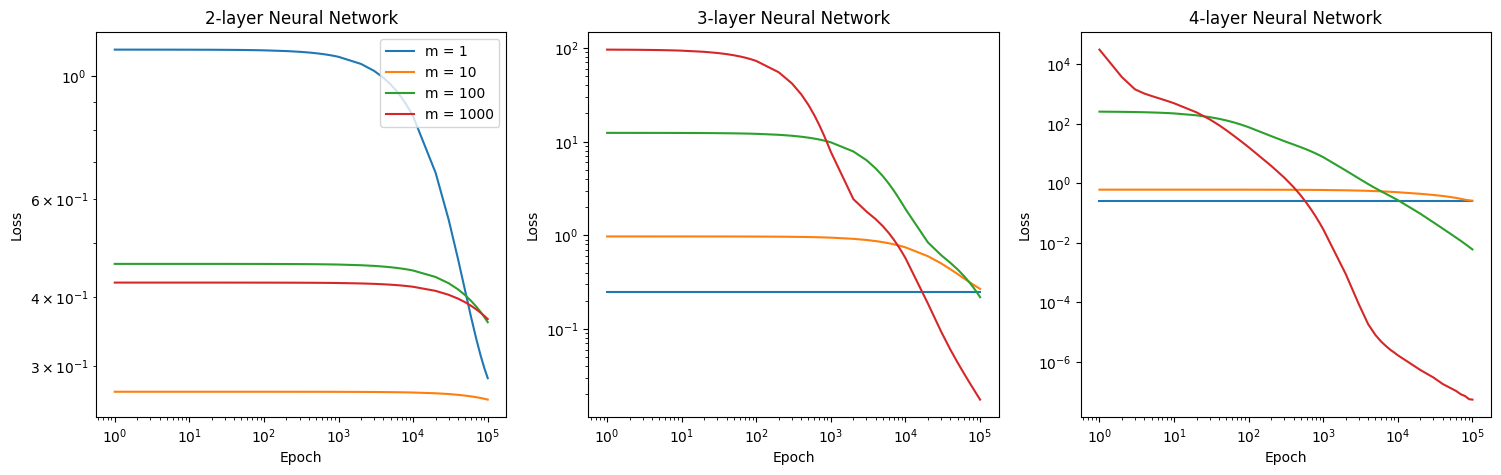

In [ ]:
fig = plt.figure(figsize=(18,5))

ax0 = fig.add_subplot(1, 3, 1)
ax1 = fig.add_subplot(1, 3, 2)
ax2 = fig.add_subplot(1, 3, 3)

for i in range(len(m)):
  ax0.loglog(plotX_0, plotY_0[i*len(plotX_0):(i+1)*len(plotX_0)], label = f'm = {m[i]}')
  if all_plotX_0mod[i] and all_plotY_0mod[i]:
    ax1.loglog(all_plotX_0mod[i], all_plotY_0mod[i], label = f'm = {m[i]}')
  if all_plotX_0mod2[i] and all_plotY_0mod2[i]:
    ax2.loglog(all_plotX_0mod2[i], all_plotY_0mod2[i], label = f'm = {m[i]}')

ax0.set_xlabel('Epoch')
ax0.set_ylabel('Loss')
ax0.set_title('2-layer Neural Network')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('3-layer Neural Network')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('4-layer Neural Network')
ax0.legend()

plt.show()